**Импортиране на нужните библиотеки**

In [74]:
import sys
print(sys.executable)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)


C:\Users\SARA\Desktop\spam_project\.venv\Scripts\python.exe


In [75]:
import os
os.listdir()

['.ipynb_checkpoints',
 '.venv',
 'shuffle_email_spam_classification.csv',
 'spam_classification_IUZ.ipynb']

**Зареждане на CSV файла**

In [76]:

# Зареждаме CSV файла (всеки ред е един имейл, а колоните са брой срещания на думи)
# Последната колона Prediction е таргетът (0=not spam, 1=spam)
df = pd.read_csv("shuffle_email_spam_classification.csv")
print(df.shape)
df.head() # Печатаме размерите на таблицата за да сме сигурни, че е заредена правилно

(5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [77]:
#Проверяваме дали има липсващи стойности или дубликати

print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
target_col = "Prediction"

# y = Prediction (последната колона), X = всички останали колони или думите

y = df[target_col]  # Таргетът е 0/1 дали имейлът е spam               
X = df.drop(columns=[target_col])  # Всички останали колони са features 
if "Email No." in X.columns: # Махаме Email No., защото е просто идентификатор и не помага за предсказването
    X = X.drop(columns=["Email No."])
X = X.fillna(0)  # Ако има липсващи стойности, ги запълваме с 0
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution (0=not spam, 1=spam):") # Проверяваме колко са 0 и колко са 1
print(y.value_counts())
print("\nClass distribution (%):")
print(y.value_counts(normalize=True))


Missing values: 0
Duplicate rows: 0
X shape: (5172, 3000)
y shape: (5172,)

Class distribution (0=not spam, 1=spam):
Prediction
0    3672
1    1500
Name: count, dtype: int64

Class distribution (%):
Prediction
0    0.709977
1    0.290023
Name: proportion, dtype: float64


**Разделяне на класове**

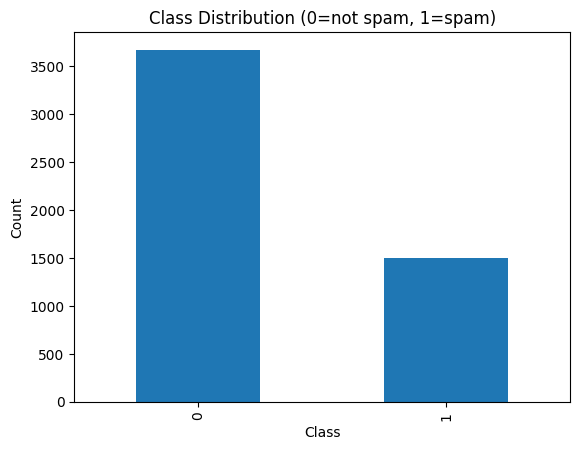

In [78]:

# Графика за броя на not spam и spam имейлите.

y.value_counts().plot(kind="bar")
plt.title("Class Distribution (0=not spam, 1=spam)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [79]:
# Разделяме данните на train и test.
# Test set го ползваме само за финална оценка 
# Stratify=y запазва съотношението на класовете и в train и test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4137, 3000) Test: (1035, 3000)


**Модел 1: Logistic Regression**

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline(steps=[
    ("scaler", StandardScaler()), # Ползваме го защото LR работи по-стабилно със скалирани данни
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced", # помага при небалансирани класове (пример тук има повече 0 отколкото 1)
        random_state=42
    ))
])
print ("LR model created.")

LR model created.


**Модел 2: Complement Naive Bayes**

In [81]:
from sklearn.naive_bayes import ComplementNB
cnb_model = ComplementNB(alpha=1.0)
print("CNB created.")

CNB created.


In [82]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Използваме 10-fold Stratified Cross-Validation, за да оценим моделите по-обективно

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)
scoring = {
    "accuracy": "accuracy", #обща точност
    "precision": "precision", #от предсказаните spam, колко са реално spam
    "recall": "recall", #от всички реални spam, колко сме хванали
    "f1": "f1", #баланс между precision и recall
    "roc_auc": "roc_auc" #колко добре разделя двата класа като цяло
}


In [83]:
def evaluate_model_cv(model, X, y, name): # Функция, която да оценява даден модел с cross validation
    scores = cross_validate(model,X,y,cv=cv,scoring=scoring,n_jobs=-1)
    
    return {
        "model": name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean()
    }


In [84]:
# Пускаме cross-validation за двата модела и сравняваме резултати

results = []
results.append(evaluate_model_cv(lr_model, X, y, "Logistic Regression"))
results.append(evaluate_model_cv(cnb_model, X, y, "Complement Naive Bayes"))

results_df = pd.DataFrame(results)
results_df

,model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,Logistic Regression,0.964617,0.914778,0.969333,0.941015,0.987395
1,Complement Naive Bayes,0.946053,0.871396,0.955333,0.911310,0.974379


**Визуализация на резултатите от Cross Validation за двата модела**

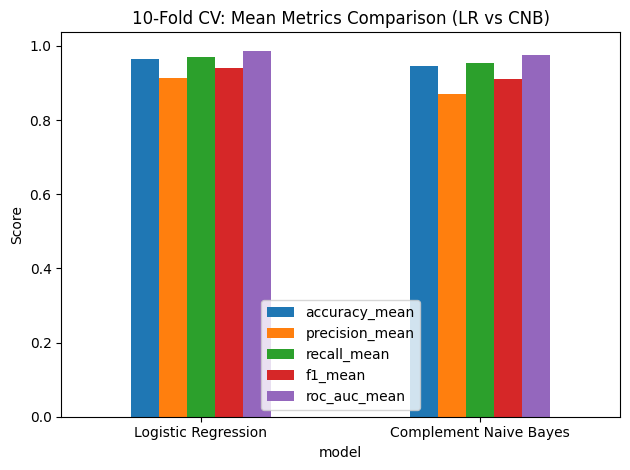

In [85]:
plot_df = results_df.set_index("model")[["accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "roc_auc_mean"]]

ax = plot_df.plot(kind="bar", rot=0)
ax.set_title("10-Fold CV: Mean Metrics Comparison (LR vs CNB)")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

In [86]:
# Избираме по-добрия модел според F1 и го тестваме на отделения test set

best_name = results_df.sort_values("f1_mean", ascending=False).iloc[0]["model"]
print("Best model by CV F1:", best_name)

best_model = lr_model if best_name == "Logistic Regression" else cnb_model

best_model.fit(X_train, y_train) # Обучаваме избрания модел на train данните

y_pred = best_model.predict(X_test) # Правим предсказване върху test данните

print(classification_report(y_test, y_pred, digits=4)) # Показваме детайлен отчет

Best model by CV F1: Logistic Regression
              precision    recall  f1-score   support

           0     0.9916    0.9633    0.9772       735
           1     0.9159    0.9800    0.9469       300

    accuracy                         0.9681      1035
   macro avg     0.9537    0.9716    0.9620      1035
weighted avg     0.9697    0.9681    0.9684      1035



**Confusion Matrix**

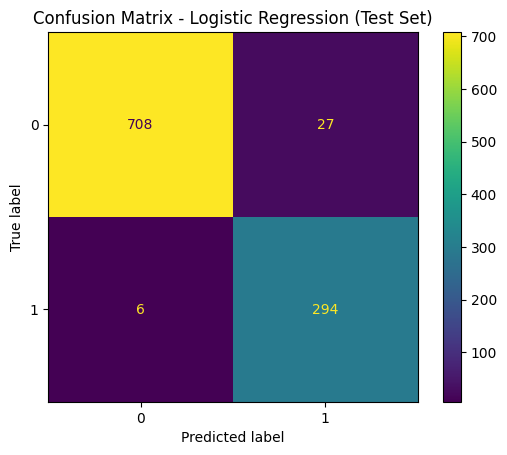

In [87]:
# Правиме confusion matrix т.е матрица на объркванията, която показва колко примера са класифицирани правилно/грешно

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_name} (Test Set)") 
plt.show()

**ROC CURVE + ROC-AUC (test set)**

Test ROC-AUC: 0.9854


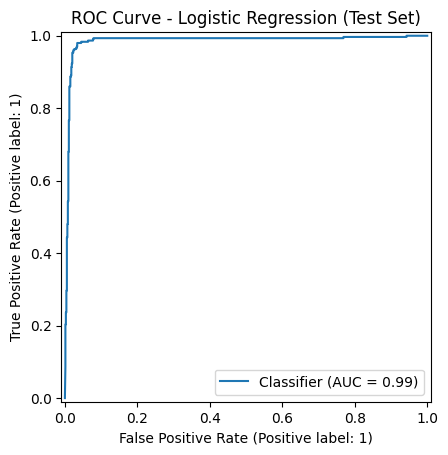

In [88]:
# ROC curve е полезна визуализация за бинарна класификация
# ROC-AUC показва общата способност на модела да разделя класовете

# Изчисляваме вероятностите за клас 1 (spam)
y_prob = best_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print("Test ROC-AUC:", round(auc, 4))
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title(f"ROC Curve - {best_name} (Test Set)")
plt.show()

**Анализ на резултатите**


В рамките на проекта беше разгледана задача за бинарна класификация на имейли(spam / not spam), като бяха използвани два основни модела  Logistic Regression и Complement Naive Bayes. Оценката на моделите беше извършена чрез 10-fold Stratified Cross-Validation, както и чрез финално тестване върху отделен test набор.
При финалната оценка на Logistic Regression върху test набора от 1035 имейла моделът класифицира правилно общо 1002 имейла, което показва много висока точност. От тях 708 имейла са правилно разпознати като not spam, а 294 имейла са правилно разпознати като spam.
Грешките са сравнително малко:  27 not spam имейла са погрешно класифицирани като spam (false positives), а само 6 spam имейла не са разпознати и са класифицирани като not spam (false negatives). Това показва, че моделът много рядко пропуска spam имейли, което е особено важно за практическо приложение.

Резултатите от класификационния отчет върху test набора показват високи стойности на precision, recall и F1-score и за двата класа, като общата точност достига 96.81%, а ROC-AUC стойността е около 0.99, което показва отлична способност на модела да разделя двата класа.

Complement Naive Bayes показва добри резултати и успява да открие голяма част от spam имейлите, но в сравнение с Logistic Regression допуска повече грешки и има по-ниски стойности на precision и F1-score.

В заключение, Logistic Regression се доказва като по-надежден и по-балансиран модел от Complement Naive Bayes, което го прави по-подходящ избор за spam класификация върху текстови данни с небалансирани класове.

**Невронна мрежа (бонус)**


In [89]:
from sklearn.neural_network import MLPClassifier

In [90]:
# Правиме невронна мрежа тип MLP (Multilayer Perceptron)
# Избираме 3 скрити слоя

mlp_model = Pipeline([
    ("scaler", StandardScaler()),  
    # Скалираме данните, защото по този начин невронните мрежи се обучават по-стабилно 
    
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),  # 3 скрити слоя
        activation="relu",                 # най-често използвана активация
        max_iter=300,                      # ограничаване на итерациите
        random_state=42
    ))
])
print("Neural Network model created.")

Neural Network model created.


In [91]:
# Обучаваме модела върху train данните и тестваме върху test данните
# Това е финалната проверка на невронната мрежа върху невиждани данни

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

print("FINAL TEST RESULTS - Neural Network (MLP)")
print(classification_report(y_test, y_pred_mlp, digits=4))

FINAL TEST RESULTS - Neural Network (MLP)
              precision    recall  f1-score   support

           0     0.9810    0.9810    0.9810       735
           1     0.9533    0.9533    0.9533       300

    accuracy                         0.9729      1035
   macro avg     0.9671    0.9671    0.9671      1035
weighted avg     0.9729    0.9729    0.9729      1035



**Confusion Matrix**


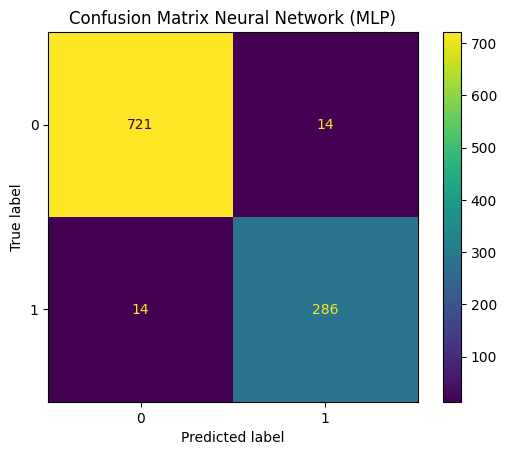

In [93]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp)
plt.title("Confusion Matrix Neural Network (MLP)")
plt.show()

**ROC CURVE + ROC-AUC**


Test ROC-AUC (MLP): 0.9905


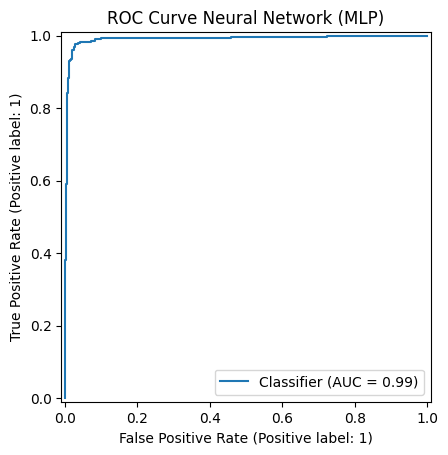

In [95]:
# При MLP имаме predict_proba, така че можем да вземем вероятността за spam (клас 1)
y_prob_mlp = mlp_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC (MLP):", round(roc_auc_score(y_test, y_prob_mlp), 4))

RocCurveDisplay.from_predictions(y_test, y_prob_mlp)
plt.title("ROC Curve Neural Network (MLP)")
plt.show()

**Финално обобщение на резултатите от 10-fold Stratified Cross-Validation за моделите Logistic Regression, Complement Naive Bayes и Neural Network (MLP)**

In [96]:

# Пускаме cross-validation за всеки модел (LR, CNB и MLP) и събираме средните метрики в една таблица

results = []

results.append(evaluate_model_cv(lr_model, X, y, "Logistic Regression"))
results.append(evaluate_model_cv(cnb_model, X, y, "Complement Naive Bayes"))
results.append(evaluate_model_cv(mlp_model, X, y, "Neural Network (MLP)"))

results_df = pd.DataFrame(results)

# Подреждаме по F1-score 
results_df_sorted = results_df.sort_values("f1_mean", ascending=False)

results_df_sorted

,model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
2,Neural Network (MLP),0.971577,0.926321,0.980667,0.952558,0.994819
0,Logistic Regression,0.964617,0.914778,0.969333,0.941015,0.987395
1,Complement Naive Bayes,0.946053,0.871396,0.955333,0.911310,0.974379


**Финален анализ**

След сравнение между трите модела чрез 10-fold Stratified Cross-Validation се установява, че невронната мрежа (MLP) постига най-добро общо представяне. Тя има най-висока средна точност (accuracy_mean = 97.16%), най-висок F1-score (0.9526) и най-добра ROC-AUC стойност (0.9948), което показва отлична способност за разграничаване между spam и not spam имейли в сравнение с Logistic Regression и Complement Naive Bayes.

Финалната оценка върху test набора от 1035 имейла потвърждава тези резултати. Моделът правилно класифицира 721 not spam и 286 spam имейла (общо 1007 правилни класификации), като допуска малък и балансиран брой грешки: 14 false positives и 14 false negatives. Класификационният отчет показва високи и близки стойности на precision, recall и F1-score за двата класа, като общата точност достига 97.29%.

В заключение, невронната мрежа се доказва като най-ефективния модел в разгледания експеримент, докато Logistic Regression и Complement Naive Bayes остават по-лесни за интерпретация, но с малко по-ниско представяне.